In [ ]:
!pip install mlflow

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

DATA_PATH = "/content/SMSSpamCollection"   # in Colab: right click the file -> Copy path
SEED = 42

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
#import data sets
sms = pd.read_csv(
    DATA_PATH, sep="\t", header=None,
    names=["LABEL", "TEXT"], quoting=3, encoding_errors="replace"
)

print(f"Rows loaded: {len(sms):,}")
sms.info()

Rows loaded: 5,574
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   LABEL   5574 non-null   object
 1   TEXT    5574 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
rows_before = len(sms)
sms = sms.dropna().drop_duplicates(subset="TEXT").reset_index(drop=True)
print(f"Duplicate or empty rows removed: {rows_before - len(sms):,}")

sms["IS_SPAM"] = (sms["LABEL"] == "spam").astype(int)
print(f"Messages kept: {len(sms):,}")
sms["LABEL"].value_counts()

Duplicate or empty rows removed: 403
Messages kept: 5,171


,count
LABEL,
ham,4518
spam,653


In [ ]:
#Pipline
mnb_pipeline = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english")),
    ("nb", MultinomialNB()),
])

X_train, X_test, y_train, y_test = train_test_split(
    sms["TEXT"], sms["IS_SPAM"],
    test_size=0.20, stratify=sms["IS_SPAM"], random_state=SEED
)
print(f"Training messages: {len(X_train):,}   Test messages: {len(X_test):,}   Spam in test set: {y_test.sum()}")

Training messages: 4,136   Test messages: 1,035   Spam in test set: 131


In [ ]:
baseline = clone(mnb_pipeline).fit(X_train, y_train)
print(f"Baseline test F1: {f1_score(y_test, baseline.predict(X_test)):.4f}")

Baseline test F1: 0.9333


In [ ]:
#Grid search and 5 fold cross
mnb_param_grid = {
    "vectorizer_ngram_range": [(1, 1), (1, 2)],
    "vectorizer_min_df": [1, 2, 5],
    "nb_alpha": [0.01, 0.1, 0.5, 1.0],
}

mnb_grid = GridSearchCV(mnb_pipeline, mnb_param_grid, cv=5, scoring="f1")
mnb_grid.fit(X_train, y_train)

mnb_best = mnb_grid.best_estimator_
print("Winning settings:", mnb_grid.best_params_)
print(f"Mean cross-validated F1: {mnb_grid.best_score_:.4f}")

grid_table = pd.DataFrame(mnb_grid.cv_results_)[["params", "mean_test_score", "std_test_score", "rank_test_score"]]
grid_table.sort_values("rank_test_score").head(5)

Winning settings: {'nb__alpha': 0.5, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': (1, 2)}
Mean cross-validated F1: 0.9442


,params,mean_test_score,std_test_score,rank_test_score
13,"{'nb__alpha': 0.5, 'vectorizer__min_df': 1, 'v...",0.944196,0.014215,1
19,"{'nb__alpha': 1.0, 'vectorizer__min_df': 1, 'v...",0.939727,0.014325,2
7,"{'nb__alpha': 0.1, 'vectorizer__min_df': 1, 'v...",0.935413,0.010634,3
0,"{'nb__alpha': 0.01, 'vectorizer__min_df': 1, '...",0.933702,0.016874,4
18,"{'nb__alpha': 1.0, 'vectorizer__min_df': 1, 'v...",0.933450,0.016993,5


Accuracy     0.9855
Precision    0.9531
Recall       0.9313
F1           0.9421
ROC AUC      0.9829


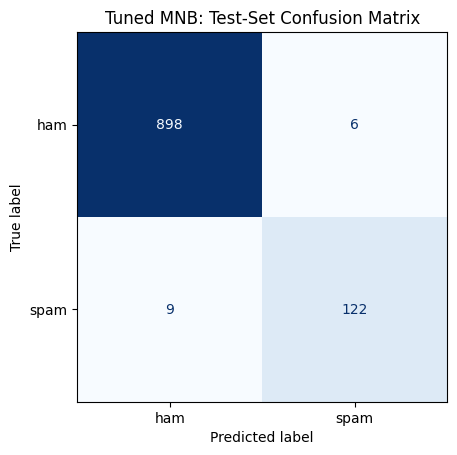

In [ ]:
test_pred = mnb_best.predict(X_test)
test_prob = mnb_best.predict_proba(X_test)[:, 1]

test_scores = pd.Series({
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred),
    "Recall": recall_score(y_test, test_pred),
    "F1": f1_score(y_test, test_pred),
    "ROC AUC": roc_auc_score(y_test, test_prob),
}).round(4)
print(test_scores.to_string())

ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred, display_labels=["ham", "spam"], cmap="Blues", colorbar=False
)
plt.title("Tuned MNB: Test Set Confusion Matrix")
plt.savefig("fig1_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

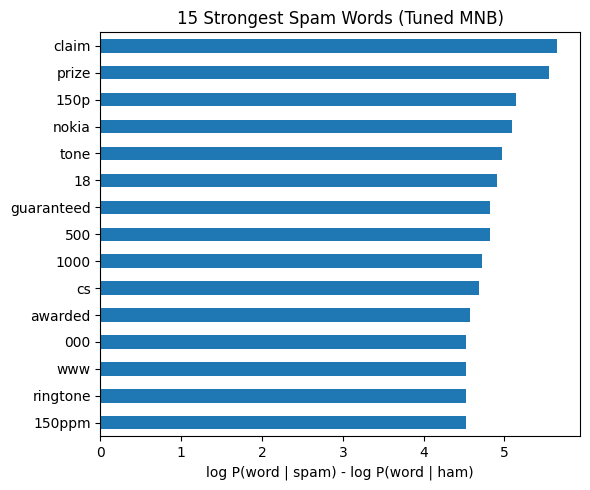

In [ ]:
word_probs = mnb_best.named_steps["nb"].feature_log_prob_
vocabulary = mnb_best.named_steps["vectorizer"].get_feature_names_out()
spam_lean = pd.Series(word_probs[1] - word_probs[0], index=vocabulary)

spam_lean.nlargest(15).sort_values().plot.barh(figsize=(6, 5))
plt.title("15 Strongest Spam Words (Tuned MNB)")
plt.xlabel("log P(word | spam) - log P(word | ham)")
plt.tight_layout()
plt.savefig("fig2_top_spam_words.png", dpi=300)
plt.show()